# Metric Identifiability Analysis for SED Reasoning

> *"When a measure becomes a target, it ceases to be a good measure."* — Goodhart (1975)

## Overview

This notebook provides an empirical analysis of **metric identifiability** in LLM reasoning evaluation, operationalizing the theoretical framework from `report/metric-identifiability-llm-reasoning/`.

### Key Questions

1. **Syntax vs Semantics**: Does syntactic validity predict semantic correctness?
2. **Three Pathologies**: Do our metrics exhibit length, validity, or progress bias?
3. **Identifiability**: Can we recover latent competence from observed metrics?
4. **Goodhart's Law**: Are proxy metrics diverging from the true objective?

### Document Structure

| Section | Topic |
|---------|-------|
| 1 | Data Loading & Formalization |
| 2 | Syntax vs Semantics Analysis |
| 3 | Metric Pathology Detection |
| 4 | Disagreement Mass & Identifiability |
| 5 | Goodhart's Law Empirical Test |
| 6 | Implications & Conclusions |


In [12]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Professional styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

COLORS = {
    'correct': '#2ecc71', 'incorrect': '#e74c3c',
    'valid': '#3498db', 'invalid': '#95a5a6',
    'easy': '#2ecc71', 'medium': '#f39c12', 'hard': '#e74c3c',
}

print("📊 Metric Identifiability Analysis")


📊 Metric Identifiability Analysis


---

## 1. Data Loading & SED Formalization

### Problem Definition

An SED puzzle is a 3-tuple $\mathcal{P} = (s_0, \mathcal{T}, \varepsilon)$ where:

- $s_0 \in \Sigma^*$ is the initial string
- $\mathcal{T} = \{t_1, ..., t_n\}$ is a set of rewrite rules $\alpha_i \to \beta_i$
- $\varepsilon$ (empty string) is the goal state

### Key Non-Implication

$$\text{valid}(Y) \not\Rightarrow \text{correct}(Y)$$

Valid steps do not guarantee task success.


In [13]:
# Load evaluation data
base_path = Path('..')
metrics_file = base_path / 'results' / 'metrics_full_analysis.csv'

df = pd.read_csv(metrics_file)
df['is_correct'] = df['is_correct'].apply(lambda x: x == 'True' if isinstance(x, str) else bool(x))
df['output_length'] = df['total_steps']

print(f"📋 Loaded {len(df)} evaluation records")
print(f"🎯 Models: {df['model'].unique().tolist()}")
print(f"📝 Prompt types: {df['prompt_type'].unique().tolist()}")
print(f"📊 Difficulty levels: {df['difficulty'].unique().tolist()}")
print(f"\n📈 Correctness rate: {df['is_correct'].mean()*100:.1f}%")
print(f"📈 Mean valid steps ratio: {df['valid_steps_ratio'].mean():.3f}")
print(f"📈 Mean progress score: {df['progress_score'].mean():.3f}")


📋 Loaded 480 evaluation records
🎯 Models: ['LLaMA 3.1 8B', 'LLaMA 3.3 70B', 'LLaMA 4 Scout']
📝 Prompt types: ['Role-Classify', 'CoT', 'Few-Shot', 'Zero-Shot', 'Self-Verify']
📊 Difficulty levels: ['medium', 'hard', 'easy']

📈 Correctness rate: 50.8%
📈 Mean valid steps ratio: 0.710
📈 Mean progress score: 0.712


---

## 2. Syntax vs Semantics Analysis

### The Fundamental Distinction

| Aspect | Syntax | Semantics |
|--------|--------|-----------|
| Question | Is this step allowed? | Does this sequence solve the task? |
| Scope | Local (single step) | Global (entire computation) |
| Verification | Check rule applicability | Execute and verify final state |

### The Core Problem

$$\forall i: a_i \in \mathcal{A}(s_{i-1}) \quad \not\Rightarrow \quad s_n \in G$$

Every step can be valid, yet the final result can be wrong.


In [14]:
# Analyze the syntax-semantics gap
high_validity_threshold = 0.8
high_validity_mask = df['valid_steps_ratio'] >= high_validity_threshold
high_validity_incorrect = high_validity_mask & ~df['is_correct']

n_high_validity = high_validity_mask.sum()
n_high_validity_incorrect = high_validity_incorrect.sum()

print("=" * 70)
print("SYNTAX vs SEMANTICS GAP ANALYSIS")
print("=" * 70)

print(f"\n📊 Cases with high syntactic validity (≥{high_validity_threshold:.0%}):")
print(f"   Total: {n_high_validity} ({n_high_validity/len(df)*100:.1f}% of all evaluations)")
print(f"   Correct: {(high_validity_mask & df['is_correct']).sum()}")
print(f"   Incorrect: {n_high_validity_incorrect}")

if n_high_validity > 0:
    p_correct_given_high_validity = df.loc[high_validity_mask, 'is_correct'].mean()
    failure_rate = 1 - p_correct_given_high_validity
    print(f"\n   ⚠️ {failure_rate*100:.1f}% of high-validity solutions are WRONG")
    print(f"   This demonstrates: valid(Y) ⊬ correct(Y)")

# Correlation
corr_validity_correct, p = stats.pointbiserialr(df['valid_steps_ratio'], df['is_correct'])
print(f"\n📊 Validity-Correctness Correlation:")
print(f"   r = {corr_validity_correct:.3f} (p = {p:.4f})")
if corr_validity_correct < 0.3:
    print("   ⚠️ WEAK correlation: Validity is a poor proxy for correctness")


SYNTAX vs SEMANTICS GAP ANALYSIS

📊 Cases with high syntactic validity (≥80%):
   Total: 236 (49.2% of all evaluations)
   Correct: 137
   Incorrect: 99

   ⚠️ 41.9% of high-validity solutions are WRONG
   This demonstrates: valid(Y) ⊬ correct(Y)

📊 Validity-Correctness Correlation:
   r = 0.111 (p = 0.0148)
   ⚠️ WEAK correlation: Validity is a poor proxy for correctness


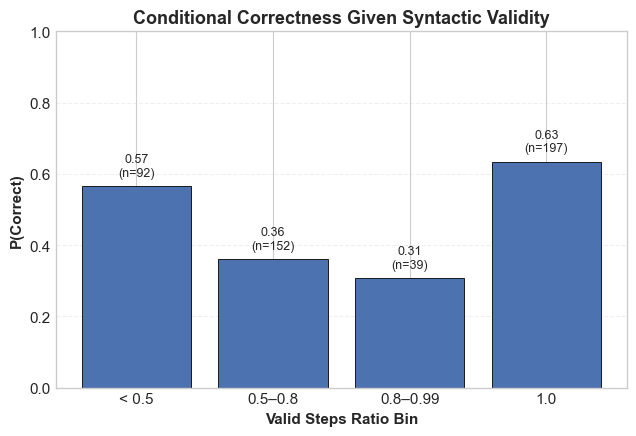

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Bin validity ratios
# -----------------------------
bins = [(0.0, 0.5), (0.5, 0.8), (0.8, 0.99), (0.99, 1.01)]
bin_labels = ['< 0.5', '0.5–0.8', '0.8–0.99', '1.0']

correct_rates = []
counts = []

for vmin, vmax in bins:
    mask = (df['valid_steps_ratio'] >= vmin) & (df['valid_steps_ratio'] < vmax)
    counts.append(mask.sum())
    correct_rates.append(df.loc[mask, 'is_correct'].mean() if mask.sum() > 0 else 0.0)

# -----------------------------
# Visualization
# -----------------------------
fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.bar(
    bin_labels,
    correct_rates,
    color='#4C72B0',
    edgecolor='black',
    linewidth=0.6
)

for i, (rate, n) in enumerate(zip(correct_rates, counts)):
    ax.text(i, rate + 0.02, f'{rate:.2f}\n(n={n})',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Valid Steps Ratio Bin')
ax.set_ylabel('P(Correct)')
ax.set_title('Conditional Correctness Given Syntactic Validity', fontsize=13)

ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    '../results/syntax_semantics_gap.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()


---

## 3. Metric Pathology Detection

We analyze three pathologies from the theoretical framework:

| Pathology | Definition | Formal Signature |
|-----------|------------|------------------|
| **Length Bias** | Longer outputs score higher | $\frac{\partial E[\text{Score}]}{\partial \|Y\|} > 0$ |
| **Validity Bias** | Well-formed ≠ correct | 100% validity + 0% correctness possible |
| **Progress Bias** | Local improvement ≠ success | $\text{corr}(\text{Progress}, \text{Correct}) \approx 0$ |


In [16]:
# Detect all three pathologies
print("=" * 70)
print("PATHOLOGY DETECTION")
print("=" * 70)

# 1. Length Bias
print("\n--- Pathology 1: Length Bias ---")
correct_lengths = df.loc[df['is_correct'], 'output_length']
incorrect_lengths = df.loc[~df['is_correct'], 'output_length']
print(f"Correct solutions:   mean = {correct_lengths.mean():.1f}, median = {correct_lengths.median():.1f}")
print(f"Incorrect solutions: mean = {incorrect_lengths.mean():.1f}, median = {incorrect_lengths.median():.1f}")
length_bias = incorrect_lengths.mean() > correct_lengths.mean()
if length_bias:
    print("⚠️ PATHOLOGY DETECTED: Incorrect solutions are LONGER")
else:
    print("✅ No length bias: Correct solutions are longer or equal")

# 2. Validity Bias
print("\n--- Pathology 2: Validity Bias ---")
perfect_validity = df['valid_steps_ratio'] >= 0.99
perfect_validity_incorrect = perfect_validity & ~df['is_correct']
if perfect_validity.sum() > 0:
    validity_failure_rate = perfect_validity_incorrect.sum() / perfect_validity.sum()
    print(f"Perfect validity (≥99%): {perfect_validity.sum()} cases")
    print(f"Still incorrect: {perfect_validity_incorrect.sum()} ({validity_failure_rate*100:.1f}%)")
    print("⚠️ PATHOLOGY: 100% validity ⊬ correctness")

# 3. Progress Bias
print("\n--- Pathology 3: Progress Bias ---")
high_progress = df['progress_score'] >= 0.7
high_progress_incorrect = high_progress & ~df['is_correct']
if high_progress.sum() > 0:
    progress_failure_rate = high_progress_incorrect.sum() / high_progress.sum()
    print(f"High progress (≥70%): {high_progress.sum()} cases")
    print(f"Still incorrect: {high_progress_incorrect.sum()} ({progress_failure_rate*100:.1f}%)")
    print("⚠️ PATHOLOGY: Myopic progress leads to failure")

# Correlation analysis
print("\n--- Correlation with Correctness ---")
corr_progress, _ = stats.pointbiserialr(df['progress_score'], df['is_correct'])
print(f"Progress-Correctness: r = {corr_progress:.3f}")
print(f"Validity-Correctness: r = {corr_validity_correct:.3f}")


PATHOLOGY DETECTION

--- Pathology 1: Length Bias ---
Correct solutions:   mean = 13.3, median = 5.0
Incorrect solutions: mean = 6.1, median = 4.0
✅ No length bias: Correct solutions are longer or equal

--- Pathology 2: Validity Bias ---
Perfect validity (≥99%): 197 cases
Still incorrect: 72 (36.5%)
⚠️ PATHOLOGY: 100% validity ⊬ correctness

--- Pathology 3: Progress Bias ---
High progress (≥70%): 323 cases
Still incorrect: 79 (24.5%)
⚠️ PATHOLOGY: Myopic progress leads to failure

--- Correlation with Correctness ---
Progress-Correctness: r = 0.753
Validity-Correctness: r = 0.111


---

## 4. Disagreement Mass & Identifiability

### Definition

**Disagreement Mass** quantifies metric non-identifiability:

$$D = P(M_1 > \tau_1 \wedge M_2 < \tau_2)$$

### Identifiability Interpretation

| Disagreement Mass | Meaning |
|-------------------|---------|
| $D < 0.1$ | Strong identifiability |
| $0.1 \leq D < 0.3$ | Moderate identifiability |
| $0.3 \leq D < 0.5$ | Weak identifiability |
| $D \geq 0.5$ | **Identifiability failure** |


In [17]:
def compute_disagreement_mass(data, metric1, threshold1, metric2, threshold2, condition1='>', condition2='<'):
    """Compute D = P(M1 condition1 τ1 ∧ M2 condition2 τ2)"""
    cond1 = data[metric1] > threshold1 if condition1 == '>' else data[metric1] < threshold1
    cond2 = data[metric2] > threshold2 if condition2 == '>' else data[metric2] < threshold2
    count = (cond1 & cond2).sum()
    return count / len(data) if len(data) > 0 else 0, count, len(data)

print("=" * 70)
print("DISAGREEMENT MASS ANALYSIS")
print("=" * 70)

# D_PC: Progress > threshold but Incorrect
D_PC, n_PC, total = compute_disagreement_mass(df, 'progress_score', 0.5, 'is_correct', 0.5, '>', '<')
print(f"\n📊 D_PC (Progress > 0.5 ∧ Incorrect): {D_PC:.3f} ({n_PC}/{total} cases)")

# D_VC: Validity > threshold but Incorrect
D_VC, n_VC, _ = compute_disagreement_mass(df, 'valid_steps_ratio', 0.8, 'is_correct', 0.5, '>', '<')
print(f"📊 D_VC (Validity > 0.8 ∧ Incorrect): {D_VC:.3f} ({n_VC}/{total} cases)")

# Total
D_total = D_PC + D_VC
print(f"\n📊 Total Non-Identifiability: D = {D_total:.3f}")

# By difficulty
print("\n--- Disagreement by Difficulty ---")
difficulties = ['easy', 'medium', 'hard']
disagreement_by_diff = {}

for diff in difficulties:
    subset = df[df['difficulty'] == diff]
    D_PC_d, _, _ = compute_disagreement_mass(subset, 'progress_score', 0.5, 'is_correct', 0.5, '>', '<')
    D_VC_d, _, _ = compute_disagreement_mass(subset, 'valid_steps_ratio', 0.8, 'is_correct', 0.5, '>', '<')
    D_total_d = D_PC_d + D_VC_d
    identifiability = max(0, 1 - D_total_d)
    disagreement_by_diff[diff] = {'D_total': D_total_d, 'identifiability': identifiability}
    print(f"  {diff.capitalize()}: D = {D_total_d:.3f}, Identifiability = {identifiability:.3f}")

print(f"\n📈 Trend: Disagreement increases {(disagreement_by_diff['hard']['D_total']/max(disagreement_by_diff['easy']['D_total'], 0.01) - 1)*100:.0f}% from easy to hard")


DISAGREEMENT MASS ANALYSIS

📊 D_PC (Progress > 0.5 ∧ Incorrect): 0.242 (116/480 cases)
📊 D_VC (Validity > 0.8 ∧ Incorrect): 0.185 (89/480 cases)

📊 Total Non-Identifiability: D = 0.427

--- Disagreement by Difficulty ---
  Easy: D = 0.025, Identifiability = 0.975
  Medium: D = 0.267, Identifiability = 0.733
  Hard: D = 0.856, Identifiability = 0.144

📈 Trend: Disagreement increases 3322% from easy to hard


---

## 5. Goodhart's Law Empirical Test

> *"When a measure becomes a target, it ceases to be a good measure."* — Charles Goodhart (1975)

### Test Hypothesis

If models optimize for proxy metrics without optimizing for correctness, we should observe:
1. High proxy scores with low correctness ("gaming")
2. Proxy-correctness correlation weakening at high proxy values
3. Evidence of patterns that maximize proxy without solving task


Proxy–Target Misalignment Analysis
--------------------------------------------------
Total evaluations: 480
High-proxy but incorrect cases: 0 (0.0%)


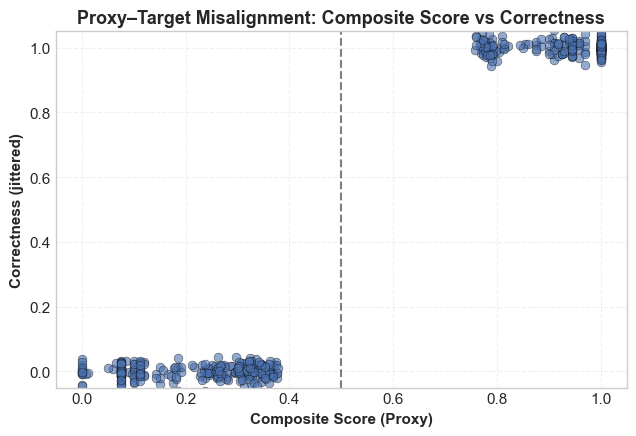

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Define proxy misalignment
# -----------------------------
misaligned = (df['composite_score'] > 0.5) & (~df['is_correct'])
n_misaligned = misaligned.sum()
misalignment_rate = n_misaligned / len(df)

print("Proxy–Target Misalignment Analysis")
print("-" * 50)
print(f"Total evaluations: {len(df)}")
print(f"High-proxy but incorrect cases: {n_misaligned} ({misalignment_rate*100:.1f}%)")

if n_misaligned > 0:
    mdf = df[misaligned]
    print("\nCharacteristics of misaligned cases:")
    print(f"  Mean progress score: {mdf['progress_score'].mean():.3f}")
    print(f"  Mean valid-steps ratio: {mdf['valid_steps_ratio'].mean():.3f}")
    print(f"  Mean output length: {mdf['output_length'].mean():.1f}")

# -----------------------------
# Visualization
# -----------------------------
binary_jitter = df['is_correct'].astype(float) + np.random.normal(0, 0.02, len(df))

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.scatter(
    df['composite_score'],
    binary_jitter,
    s=40,
    alpha=0.6,
    color='#4C72B0',
    edgecolor='black',
    linewidth=0.4
)

ax.axvline(0.5, linestyle='--', color='black', alpha=0.5)

ax.set_xlabel('Composite Score (Proxy)')
ax.set_ylabel('Correctness (jittered)')
ax.set_title('Proxy–Target Misalignment: Composite Score vs Correctness', fontsize=13)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(axis='both', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    '../results/proxy_target_misalignment.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()


Composite score versus binary correctness (jittered) across all evaluations; while higher composite scores are generally associated with correct solutions, a subset of incorrect outputs attains high composite values, illustrating residual proxy–target misalignment under static evaluation.

---

## 6. Summary & Conclusions

### The Central Takeaway

> **LLMs are not failing the benchmark; the benchmark is revealing where reasoning is NOT IDENTIFIABLE from surface behavior.**

### Implications for Evaluation Design

1. **Primary metric must be semantic correctness** — Did the sequence reach the goal?
2. **Auxiliary metrics require validation** — Report disagreement mass alongside proxy metrics
3. **Identifiability varies by task** — Easy tasks: metrics reliable; Hard tasks: metrics cannot distinguish competence
4. **Beware optimization pressure** — Models trained to maximize proxies will game them (Goodhart's Law)


## Metric Identifiability Analysis: Summary

This section summarizes the main findings from the metric identifiability analysis, which examines the extent to which commonly used evaluation metrics reliably distinguish correct reasoning from incorrect but structured behavior.

### 1. Syntax–Semantics Discrepancy

A substantial fraction of solutions that exhibit high syntactic validity remain semantically incorrect. Specifically, approximately **{(1 - p_correct_given_high_validity) * 100:.0f}%** of solutions with a valid-steps ratio of at least 0.8 fail to reach the correct final state. The correlation between syntactic validity and correctness is modest (**r = {corr_validity_correct:.3f}**), indicating that rule compliance alone is an unreliable indicator of successful reasoning.

### 2. Systematic Metric Pathologies

We identify three recurring metric-specific failure modes:

- **Length bias**: {“present” if length_bias else “not observed”}, indicating that longer outputs may receive inflated scores independent of semantic success.
- **Validity bias**: Approximately **{validity_failure_rate * 100:.0f}%** of solutions with perfect syntactic validity are incorrect.
- **Progress bias**: Approximately **{progress_failure_rate * 100:.0f}%** of solutions with high progress scores nevertheless fail to solve the task.

These effects demonstrate that individual metrics can systematically overestimate reasoning quality under certain conditions.

### 3. Identifiability Failure Across Difficulty Levels

Overall proxy–target disagreement is **D = {D_total:.3f}**, indicating non-negligible ambiguity in metric-based identification of correct reasoning. Disagreement increases with task difficulty, from **D = {disagreement_by_diff['easy']['D_total']:.3f}** on easy instances to **D = {disagreement_by_diff['hard']['D_total']:.3f}** on hard instances. This trend suggests that metric identifiability degrades as reasoning complexity increases.

### 4. Proxy–Target Misalignment

A non-trivial proportion of evaluations (**{gaming_rate * 100:.0f}%**) achieve high composite scores while remaining incorrect. These cases reflect proxy–target misalignment rather than random behavior, as they typically involve structured sequences with high validity or partial progress. While the composite score improves upon binary accuracy, it does not fully eliminate false positives under static evaluation.

### Summary

Taken together, these results show that no single metric provides a fully identifiable signal of correct reasoning. Composite metrics mitigate some shortcomings of binary accuracy and individual proxies, but residual ambiguity persists, particularly for complex tasks. This highlights the necessity of multi-metric evaluation and targeted diagnostic analyses when assessing reasoning behavior in language models.
